In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [9]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.6 MB/s eta 0:00:00


In [2]:
from pathlib import Path

RUN_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/gan/"
    "m500_finetuning_full/"
    "00000-stylegan2-melanoma_train_512-gpus1-batch16-gamma32"
)

for path in sorted(RUN_DIR.glob("network-snapshot-*.pkl")):
    print(path.name)

network-snapshot-000000.pkl
network-snapshot-000040.pkl
network-snapshot-000080.pkl
network-snapshot-000120.pkl
network-snapshot-000160.pkl
network-snapshot-000200.pkl
network-snapshot-000240.pkl
network-snapshot-000280.pkl
network-snapshot-000320.pkl
network-snapshot-000360.pkl
network-snapshot-000400.pkl
network-snapshot-000440.pkl
network-snapshot-000480.pkl
network-snapshot-000500.pkl


In [3]:
!nvidia-smi

Mon Jul 27 16:44:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   36C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
from pathlib import Path

CKPT_200 = RUN_DIR / "network-snapshot-000200.pkl"
CKPT_500 = RUN_DIR / "network-snapshot-000500.pkl"

print("200 exists:", CKPT_200.exists())
print("500 exists:", CKPT_500.exists())

200 exists: True
500 exists: True


In [18]:
OUT_200 = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/gan/generated_200kimg"
)
OUT_500 = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/gan/generated_500kimg"
)

OUT_200_FULL = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/gan/generated_200kimg_full"
)

OUT_500_FULL = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/gan/generated_500kimg_full"
)

OUT_200_FULL.mkdir(parents=True, exist_ok=True)
OUT_500_FULL.mkdir(parents=True, exist_ok=True)
OUT_200.mkdir(parents=True, exist_ok=True)
OUT_500.mkdir(parents=True, exist_ok=True)

In [6]:
!git clone https://github.com/NVlabs/stylegan3.git /content/stylegan3

Cloning into '/content/stylegan3'...
remote: Enumerating objects: 212, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 212 (delta 101), reused 96 (delta 96), pack-reused 46 (from 1)
Receiving objects: 100% (212/212), 4.16 MiB | 20.78 MiB/s, done.
Resolving deltas: 100% (107/107), done.


In [12]:
from pathlib import Path

custom_ops_path = Path(
    "/content/stylegan3/torch_utils/custom_ops.py"
)

text = custom_ops_path.read_text()

patch = """
# Compatibility patch for PyTorch >= 2.9.
# Newer PyTorch versions no longer automatically register JIT extensions
# in sys.modules, but StyleGAN3 expects that old behaviour.
import sys

_original_cpp_extension_load = torch.utils.cpp_extension.load

def _cpp_extension_load_and_register(name, *args, **kwargs):
    module = _original_cpp_extension_load(
        name=name,
        *args,
        **kwargs
    )

    if module is not None:
        sys.modules[name] = module

    return module

torch.utils.cpp_extension.load = _cpp_extension_load_and_register
"""

marker = "# Compatibility patch for PyTorch >= 2.9."

if marker not in text:
    insertion_point = "from torch.utils.file_baton import FileBaton\n"

    if insertion_point not in text:
        raise RuntimeError(
            "Could not find the expected insertion point in custom_ops.py"
        )

    text = text.replace(
        insertion_point,
        insertion_point + patch
    )

    custom_ops_path.write_text(text)

    print("StyleGAN3 compatibility patch applied.")
else:
    print("Compatibility patch already present.")

StyleGAN3 compatibility patch applied.


In [13]:
%cd /content/stylegan3

/content/stylegan3


In [14]:
# test

!python gen_images.py \
    --network="{CKPT_200}" \
    --outdir="{OUT_200}" \
    --seeds=0-15 \
    --trunc=1

Loading networks from "/content/drive/MyDrive/bachelor_thesis_data/gan/m500_finetuning_full/00000-stylegan2-melanoma_train_512-gpus1-batch16-gamma32/network-snapshot-000200.pkl"...
Generating image for seed 0 (0/16) ...
Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.
/content/stylegan3/gen_images.py:137: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PIL.Image.fromarray(img[0].cpu().numpy(), 'RGB').save(f'{outdir}/seed{seed:04d}.png')
Generating image for seed 1 (1/16) ...
Generating image for seed 2 (2/16) ...
Generating image for seed 3 (3/16) ...
Generating image for seed 4 (4/16) ...
Generating image for seed 5 (5/16) ...
Generating image for seed 6 (6/16) ...
Generating image for seed 7 (7/16) ...
Generating image for seed 8 (8/16) ...
Generating image for seed 9 (9/16) ...
Generating image for seed 10 (10/16) ...
Generating image for seed 11 (11/16) ...
Generating image 

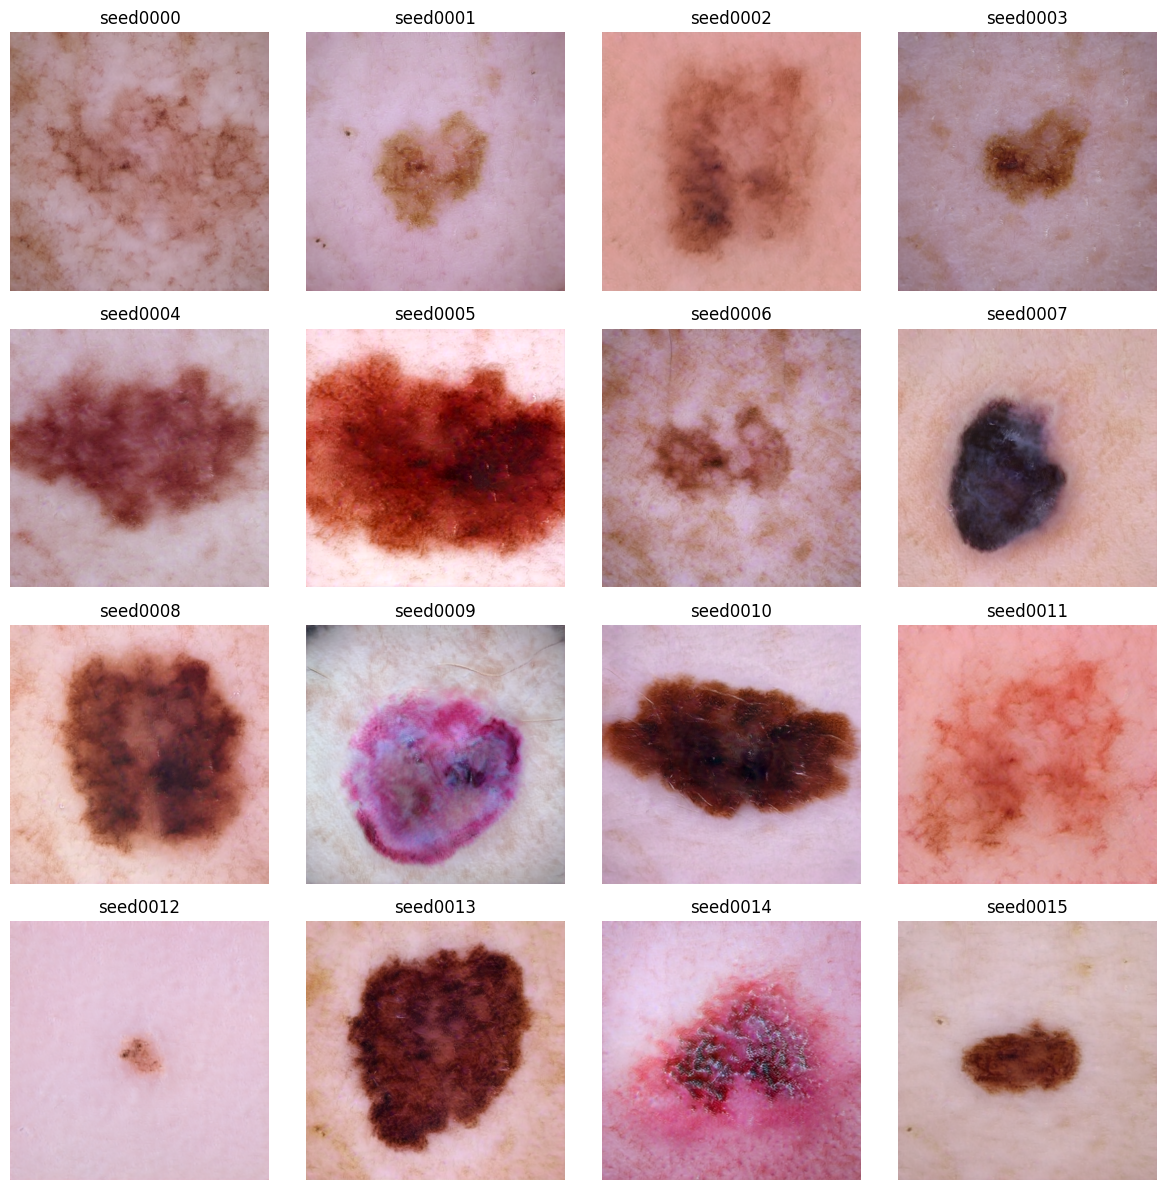

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

sample_paths = sorted(OUT_200.glob("*.png"))

plt.figure(figsize=(12, 12))

for index, path in enumerate(sample_paths[:16]):
    image = Image.open(path)

    plt.subplot(4, 4, index + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(path.stem)

plt.tight_layout()
plt.show()

In [16]:
# test

!python gen_images.py \
    --network="{CKPT_500}" \
    --outdir="{OUT_500}" \
    --seeds=0-15 \
    --trunc=1

Loading networks from "/content/drive/MyDrive/bachelor_thesis_data/gan/m500_finetuning_full/00000-stylegan2-melanoma_train_512-gpus1-batch16-gamma32/network-snapshot-000500.pkl"...
Generating image for seed 0 (0/16) ...
Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.
/content/stylegan3/gen_images.py:137: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  PIL.Image.fromarray(img[0].cpu().numpy(), 'RGB').save(f'{outdir}/seed{seed:04d}.png')
Generating image for seed 1 (1/16) ...
Generating image for seed 2 (2/16) ...
Generating image for seed 3 (3/16) ...
Generating image for seed 4 (4/16) ...
Generating image for seed 5 (5/16) ...
Generating image for seed 6 (6/16) ...
Generating image for seed 7 (7/16) ...
Generating image for seed 8 (8/16) ...
Generating image for seed 9 (9/16) ...
Generating image for seed 10 (10/16) ...
Generating image for seed 11 (11/16) ...
Generating image 

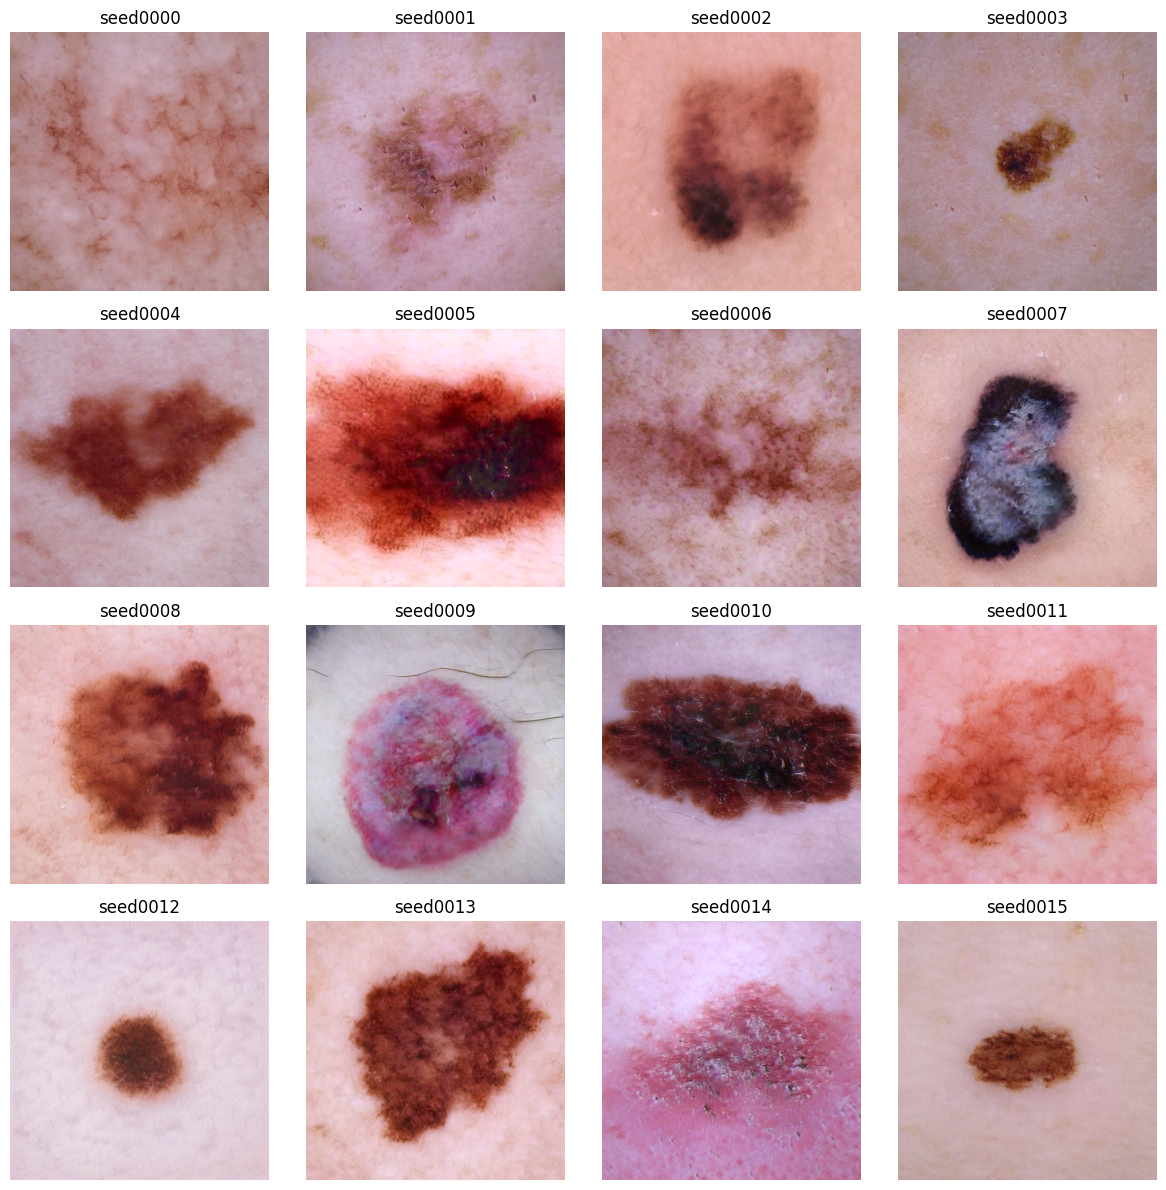

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

sample_paths = sorted(OUT_500.glob("*.png"))

plt.figure(figsize=(12, 12))

for index, path in enumerate(sample_paths[:16]):
    image = Image.open(path)

    plt.subplot(4, 4, index + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(path.stem)

plt.tight_layout()
plt.show()

In [20]:
!python gen_images.py \
    --network="{CKPT_200}" \
    --outdir="{OUT_200_FULL}" \
    --seeds=0-6999 \
    --trunc=1

Datele de ieșire de afișat au fost trunchiate la ultimele 5000 linii.
Generating image for seed 2000 (2000/7000) ...
Generating image for seed 2001 (2001/7000) ...
Generating image for seed 2002 (2002/7000) ...
Generating image for seed 2003 (2003/7000) ...
Generating image for seed 2004 (2004/7000) ...
Generating image for seed 2005 (2005/7000) ...
Generating image for seed 2006 (2006/7000) ...
Generating image for seed 2007 (2007/7000) ...
Generating image for seed 2008 (2008/7000) ...
Generating image for seed 2009 (2009/7000) ...
Generating image for seed 2010 (2010/7000) ...
Generating image for seed 2011 (2011/7000) ...
Generating image for seed 2012 (2012/7000) ...
Generating image for seed 2013 (2013/7000) ...
Generating image for seed 2014 (2014/7000) ...
Generating image for seed 2015 (2015/7000) ...
Generating image for seed 2016 (2016/7000) ...
Generating image for seed 2017 (2017/7000) ...
Generating image for seed 2018 (2018/7000) ...
Generating image for seed 2019 (2019/

In [21]:
!python gen_images.py \
    --network="{CKPT_500}" \
    --outdir="{OUT_500_FULL}" \
    --seeds=0-6999 \
    --trunc=1

Datele de ieșire de afișat au fost trunchiate la ultimele 5000 linii.
Generating image for seed 2000 (2000/7000) ...
Generating image for seed 2001 (2001/7000) ...
Generating image for seed 2002 (2002/7000) ...
Generating image for seed 2003 (2003/7000) ...
Generating image for seed 2004 (2004/7000) ...
Generating image for seed 2005 (2005/7000) ...
Generating image for seed 2006 (2006/7000) ...
Generating image for seed 2007 (2007/7000) ...
Generating image for seed 2008 (2008/7000) ...
Generating image for seed 2009 (2009/7000) ...
Generating image for seed 2010 (2010/7000) ...
Generating image for seed 2011 (2011/7000) ...
Generating image for seed 2012 (2012/7000) ...
Generating image for seed 2013 (2013/7000) ...
Generating image for seed 2014 (2014/7000) ...
Generating image for seed 2015 (2015/7000) ...
Generating image for seed 2016 (2016/7000) ...
Generating image for seed 2017 (2017/7000) ...
Generating image for seed 2018 (2018/7000) ...
Generating image for seed 2019 (2019/